<a href="https://colab.research.google.com/github/turnleftorgo/Deep_learning/blob/main/Machine_learning_Assignment1_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Lexi Li

34217886

# Question 1

In [ ]:
from sklearn.datasets import load_diabetes
dataset1 = load_diabetes()


print(dataset1.DESCR)


"""
Age

Sex

Body Mass Index (BMI)

Average Blood Pressure

S1 (a blood serum measurement)

S2 (a blood serum measurement)

S3 (a blood serum measurement)

S4 (a blood serum measurement)

S5 (a blood serum measurement)

S6 (a blood serum measurement)

"""

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

'\nAge\n\nSex\n\nBody Mass Index (BMI)\n\nAverage Blood Pressure\n\nS1 (a blood serum measurement)\n\nS2 (a blood serum measurement)\n\nS3 (a blood serum measurement)\n\nS4 (a blood serum measurement)\n\nS5 (a blood serum measurement)\n\nS6 (a blood serum measurement)\n\n'

In [ ]:
dataset1.data[:10]


array([[ 0.03807591,  0.05068012,  0.06169621,  0.02187239, -0.0442235 ,
        -0.03482076, -0.04340085, -0.00259226,  0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, -0.02632753, -0.00844872,
        -0.01916334,  0.07441156, -0.03949338, -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, -0.00567042, -0.04559945,
        -0.03419447, -0.03235593, -0.00259226,  0.00286131, -0.02593034],
       [-0.08906294, -0.04464164, -0.01159501, -0.03665608,  0.01219057,
         0.02499059, -0.03603757,  0.03430886,  0.02268774, -0.00936191],
       [ 0.00538306, -0.04464164, -0.03638469,  0.02187239,  0.00393485,
         0.01559614,  0.00814208, -0.00259226, -0.03198764, -0.04664087],
       [-0.09269548, -0.04464164, -0.04069594, -0.01944183, -0.06899065,
        -0.07928784,  0.04127682, -0.0763945 , -0.04117617, -0.09634616],
       [-0.04547248,  0.05068012, -0.04716281, -0.01599898, -0.04009564,
        -0.02480001,  0.00077881, -0.03949338

In [ ]:
dataset1.target[:10] # quantitative measure of disease progression

array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310.])

In [ ]:
import numpy as np

def train_test_split(x, y, train_size=0.9, random_state=None):
    RNG = np.random.default_rng(random_state)
    N = len(x)
    N_train = round(N*train_size)
    idx_train = RNG.choice(N, N_train, replace=False)
    idx_test = np.setdiff1d(np.arange(N), idx_train)
    RNG.shuffle(idx_test)
    return x[idx_train], x[idx_test], y[idx_train], y[idx_test]

x_train, x_test, y_train, y_test = train_test_split(dataset1.data, dataset1.target, train_size=0.9, random_state=1)

In [ ]:
from scipy.spatial import KDTree
from scipy.stats import mode

class KnnRegressor:

    def __init__(self, k):
        self.k = k

    def fit(self, x, y):
        self.y_train_ = y
        self.x_train_kdtree_ = KDTree(x)                                          # a data structure that let us search the nearest neighbour in O(logn) time
        return self

    def predict(self, x):
        _, neighbours = self.x_train_kdtree_.query(x, k=self.k)                   #  get the K-nearest neighbour | distance and indice to each neibour
        neighbours = neighbours.reshape(len(x), self.k)

        neighbour_targets = self.y_train_[neighbours]                             #  pull out the target values that correspond to each neighbour index. because this is a regression problem.
        predict_label = neighbour_targets.mean(axis=1)                            #  Calculate the mean neighbout target value as perdict value

        return predict_label

In [ ]:
knn = KnnRegressor(k=7)
knn.fit(x_train, y_train)
y_train_pred = knn.predict(x_train)
y_test_pred = knn.predict(x_test)


In [ ]:
def abs_error(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

train_error = abs_error(y_train, y_train_pred)
test_error = abs_error(y_test, y_test_pred)

print(f"Train error: {train_error}")
print(f"Test error: {test_error}")

# using absolute error to describe deviation from true value here

Train error: 40.05527638190955
Test error: 47.97402597402597


# Question 2

In [ ]:
import numpy as np


class LFold:

    def __init__(self, n_splits=5):

        self.n_splits = n_splits


    def get_n_splits(self, X=None, y=None, groups=None):

        return self.n_splits

    def split(self, X, y=None, groups=None):

        X = np.asarray(X)                                                              # Transform input to array
        n_samples = X.shape[0]
        indices = np.arange(n_samples)

        fold_sizes = np.full(self.n_splits, n_samples // self.n_splits, dtype=int)
        fold_sizes[:n_samples % self.n_splits] += 1                                    # Make sure every elment is in group


        current = 0
        for i in fold_sizes:
            start, end = current, current + i
            test_idx = indices[start:end]
            train_idx = np.concatenate([indices[:start], indices[end:]])

            current = end

            yield train_idx, test_idx

In [ ]:
for idx_train, idx_test in LFold(5).split(list(range(21))):
    print(idx_train, idx_test)

[ 5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20] [0 1 2 3 4]
[ 0  1  2  3  4  9 10 11 12 13 14 15 16 17 18 19 20] [5 6 7 8]
[ 0  1  2  3  4  5  6  7  8 13 14 15 16 17 18 19 20] [ 9 10 11 12]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 17 18 19 20] [13 14 15 16]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16] [17 18 19 20]


In [ ]:
from sklearn.datasets import load_diabetes
dataset = load_diabetes()
X, y = dataset.data, dataset.target

def mse(y_true, y_pred):
    return np.mean(np.square(y_true - y_pred))

In [ ]:
k_range = range(1,31)
results = []

for k in k_range:

    knn = KnnRegressor(k=k)

    train_mse_scores = []
    test_mse_scores = []

    # Perform L-fold CV

    for train_idx, test_idx in LFold(10).split(X,y):

        # Split data
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # Fit and predict
        knn.fit(X_train, y_train)
        y_train_pred = knn.predict(X_train)
        y_test_pred = knn.predict(X_test)

        # Compute MSE
        train_mse = mse(y_train, y_train_pred)
        test_mse = mse(y_test, y_test_pred)

        train_mse_scores.append(train_mse)
        test_mse_scores.append(test_mse)

    # Compute mean and std of MSE scores
    train_mse_mean = np.mean(train_mse_scores)
    train_mse_std = np.std(train_mse_scores)
    test_mse_mean = np.mean(test_mse_scores)
    test_mse_std = np.std(test_mse_scores)

    results.append({
        'k': k,
        'train_mse_mean': train_mse_mean,
        'train_mse_std': train_mse_std,
        'test_mse_mean': test_mse_mean,
        'test_mse_std': test_mse_std
    })


best_result = min(results, key=lambda x: x['test_mse_mean'])
best_k = best_result['k']
best_test_mse = best_result['test_mse_mean']
best_test_mse_std = best_result['test_mse_std']

print(f"Best k: {best_k}")
print(f"Best Test MSE: {best_test_mse:.4f} ± {best_test_mse_std:.4f}")
print("\nDetailed Results:")

for result in results:
    print(f"k={result['k']}:")
    print(f"  Train MSE: {result['train_mse_mean']:.4f} ± {result['train_mse_std']:.4f}")
    print(f"  Test MSE: {result['test_mse_mean']:.4f} ± {result['test_mse_std']:.4f}")



Best k: 19
Best Test MSE: 3238.9152 ± 582.9894

Detailed Results:
k=1:
  Train MSE: 0.0000 ± 0.0000
  Test MSE: 6107.9064 ± 1396.0803
k=2:
  Train MSE: 1478.8510 ± 44.2100
  Test MSE: 4589.8444 ± 821.3522
k=3:
  Train MSE: 1976.4497 ± 60.7239
  Test MSE: 4127.1100 ± 902.4088
k=4:
  Train MSE: 2264.2371 ± 62.3562
  Test MSE: 3789.3955 ± 802.0324
k=5:
  Train MSE: 2394.4947 ± 61.2017
  Test MSE: 3764.7386 ± 743.1029
k=6:
  Train MSE: 2548.0737 ± 65.0172
  Test MSE: 3625.1543 ± 728.3147
k=7:
  Train MSE: 2617.3045 ± 66.5975
  Test MSE: 3628.6146 ± 595.5112
k=8:
  Train MSE: 2660.2537 ± 54.3969
  Test MSE: 3537.0091 ± 622.7153
k=9:
  Train MSE: 2706.2364 ± 59.5003
  Test MSE: 3437.5681 ± 587.7535
k=10:
  Train MSE: 2761.0196 ± 64.0880
  Test MSE: 3420.9398 ± 555.4828
k=11:
  Train MSE: 2796.4919 ± 54.3901
  Test MSE: 3405.6546 ± 613.2840
k=12:
  Train MSE: 2828.7236 ± 55.7734
  Test MSE: 3373.4386 ± 606.8481
k=13:
  Train MSE: 2840.9661 ± 55.6511
  Test MSE: 3310.2687 ± 626.9749
k=14:
  Tr

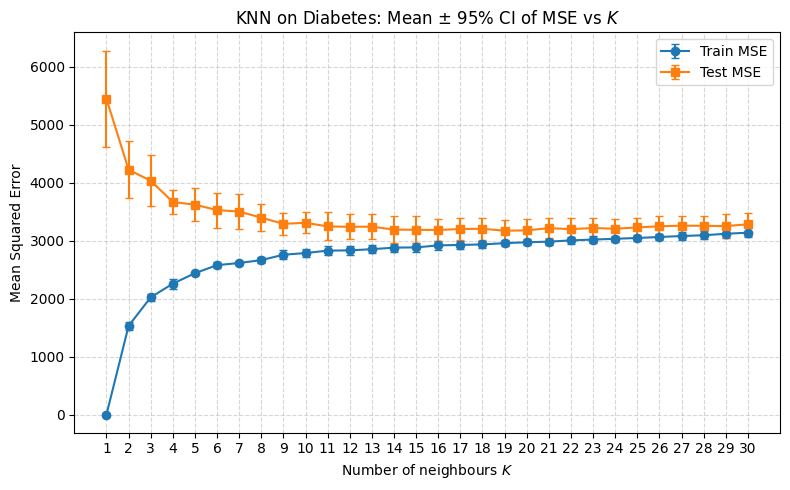

In [ ]:
import numpy as np
import matplotlib.pyplot as plt



k_range = range(1, 31)
L = 5                               # number of folds
alpha = 1.96                        # for 95% CI: m ± 1.96·(s/√L)


train_means = []
train_errs  = []
test_means  = []
test_errs   = []


for k in k_range:

    knn = KnnRegressor(k=k)
    train_scores = []
    test_scores  = []


    for train_idx, test_idx in LFold(n_splits=L).split(X,y):

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        knn.fit(X_train, y_train)
        y_train_pred = knn.predict(X_train)
        y_test_pred  = knn.predict(X_test)

        train_scores.append(mse(y_train, y_train_pred))
        test_scores .append(mse(y_test,  y_test_pred ))

    # Compute sample mean and sample std
    m_tr = np.mean(train_scores)
    s_tr = np.std( train_scores, ddof=1)
    se_tr = alpha*(s_tr / np.sqrt(L))

    m_te = np.mean(test_scores)
    s_te = np.std( test_scores,  ddof=1)
    se_te = alpha*(s_te / np.sqrt(L))

    # store for plotting
    train_means.append(m_tr)
    train_errs .append(se_tr)
    test_means .append(m_te)
    test_errs  .append(se_te)

# Plotting
plt.figure(figsize=(8,5))

plt.errorbar(k_range, train_means, train_errs, label='Train MSE', marker='o', capsize=3)
plt.errorbar(k_range, test_means,  test_errs,  label='Test MSE',  marker='s', capsize=3)

plt.xlabel('Number of neighbours $K$')
plt.ylabel('Mean Squared Error')
plt.title('KNN on Diabetes: Mean ± 95% CI of MSE vs $K$')
plt.legend()

plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


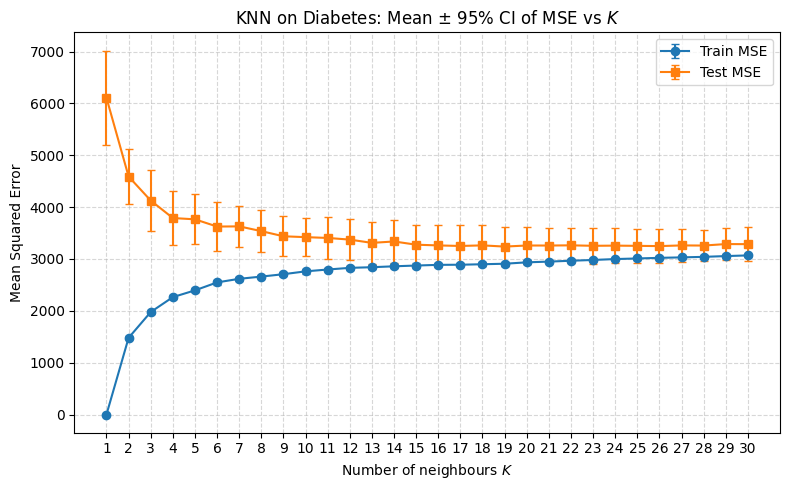

In [ ]:
import numpy as np
import matplotlib.pyplot as plt



k_range = range(1, 31)
L = 10                              # number of folds
alpha = 1.96                        # for 95% CI: m ± 1.96·(s/√L)


train_means = []
train_errs  = []
test_means  = []
test_errs   = []


for k in k_range:

    knn = KnnRegressor(k=k)
    train_scores = []
    test_scores  = []


    for train_idx, test_idx in LFold(n_splits=L).split(X,y):

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        knn.fit(X_train, y_train)
        y_train_pred = knn.predict(X_train)
        y_test_pred  = knn.predict(X_test)

        train_scores.append(mse(y_train, y_train_pred))
        test_scores .append(mse(y_test,  y_test_pred ))

    # Compute sample mean and sample std
    m_tr = np.mean(train_scores)
    s_tr = np.std( train_scores, ddof=1)
    se_tr = alpha*(s_tr / np.sqrt(L))

    m_te = np.mean(test_scores)
    s_te = np.std( test_scores,  ddof=1)
    se_te = alpha*(s_te / np.sqrt(L))

    # store for plotting
    train_means.append(m_tr)
    train_errs .append(se_tr)
    test_means .append(m_te)
    test_errs  .append(se_te)

# Plotting
plt.figure(figsize=(8,5))

plt.errorbar(k_range, train_means, train_errs, label='Train MSE', marker='o', capsize=3)
plt.errorbar(k_range, test_means,  test_errs,  label='Test MSE',  marker='s', capsize=3)

plt.xlabel('Number of neighbours $K$')
plt.ylabel('Mean Squared Error')
plt.title('KNN on Diabetes: Mean ± 95% CI of MSE vs $K$')
plt.legend()

plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


The effect of parameter L

When L is in a smaller size of 5, the KNN model will converge faster.

KNN model starts to converge at K = 14 when L = 5, while it starts to converge at K = 19 when L = 10.

The effect of parameter K

case 1 : L = 5

It is underfitting when k < 8

And it overfitting when k > 14 ( The test error didn't go down for a period )

case 2 : L = 10

It is underfitting when k < 11

And it overfitting when k > 19


# Question 3

In [ ]:
from sklearn.base import BaseEstimator

class KnnRegressorCV(BaseEstimator):
    def __init__(self, k_range=list(range(1, 21)), cv=LFold(5)):
        self.k_range = k_range
        self.cv = cv
        self.best_k = None
        self.model = None

    def fit(self, X, y):

        scores = []

        for k in self.k_range:

            model = KnnRegressor(k=k)
            fold_scores = []

            for train_idx, val_idx in self.cv.split(X):                          # use X to do L fold CV

                X_train, X_val = X[train_idx], X[val_idx]
                y_train, y_val = y[train_idx], y[val_idx]

                model.fit(X_train, y_train)

                y_pred = model.predict(X_val)
                mse1 = mse(y_val, y_pred)
                fold_scores.append(mse1)

            avg_mse = np.mean(fold_scores)
            scores.append(avg_mse)

        self.best_k = self.k_range[np.argmin(scores)]
        self.model = KnnRegressor(k=self.best_k)                                 # Set up KnnRegressor
        self.model.fit(X, y)

        return self

    def predict(self, X):

        return self.model.predict(X)



In [ ]:
x_train, x_test, y_train, y_test = train_test_split(dataset1.data, dataset1.target, train_size=0.8, random_state=1)

knn_cv = KnnRegressorCV(k_range=list(range(1, 21)), cv=LFold(20))

knn_cv.fit(x_train, y_train)
best_k_inner = knn_cv.best_k

y_train_pred = knn_cv.predict(x_train)
y_test_pred = knn_cv.predict(x_test)

mse_model = mse(y_test, y_test_pred)

outer_mses = []
for k in knn_cv.k_range:
    model = KnnRegressor(k=k)
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    outer_mses.append(mse(y_test, y_pred))

best_k_outer = knn_cv.k_range[np.argmin(outer_mses)]

mse_best_outer = np.min(outer_mses)

# 6) Report
print(f"Best k (inner CV):              {best_k_inner}")
print(f"Best k (outer test-set MSE):    {best_k_outer}")
print(f"MSE of inner‑chosen model:     {mse_model:.4f}")
print(f"MSE of outer‑best model:       {mse_best_outer:.4f}")

Best k (inner CV):              16
Best k (outer test-set MSE):    18
MSE of inner‑chosen model:     2909.5417
MSE of outer‑best model:       2815.4364


The inner CV is closly approximate the best k, and the difference showed above is mainly because: the KnnRegressorCV can only see 80% of the data. And the number of L also influence the correctness of k, because it have a connection with the mean error, and the mean error is the key factor that we decide which k is the best inside inner CV process. a bigger L give less bias toward the overall best k , in general.